In [4]:
# Install any missing packages (XGBoost may not be pre-installed in Colab)
!pip install xgboost -q

# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
from google.colab import files

print("Please select your Excel file (customer.churn.datak.xlsx) from your local machine.")
uploaded = files.upload()

# Get the filename (the first key in the uploaded dictionary)
file_name = list(uploaded.keys())[0]
print(f"\nUploaded file: {file_name}")

Please select your Excel file (customer.churn.datak.xlsx) from your local machine.


Saving customer.churn.datak.xlsx to customer.churn.datak (1).xlsx

Uploaded file: customer.churn.datak (1).xlsx


In [6]:
# Read the Excel file – we know the sheet name is 'customer_churn_data'
df = pd.read_excel(file_name, sheet_name='customer_churn_data')

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset shape: (5880, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


In [7]:
# Column names
print("Column names:")
print(df.columns.tolist())

# Data types and non-null counts
print("\nData info:")
df.info()

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
df.describe()

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   object 
 1   gender            5880 non-null   object 
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   object 
 4   Dependents        5880 non-null   object 
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   object 
 7   MultipleLines     5880 non-null   object 
 8   InternetService   5880 non-null   object 
 9   OnlineSecurity    588

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.500680,36.549150,70.157779,2566.813165
std,0.500042,20.909674,28.804615,1910.017743
min,0.000000,1.000000,20.000000,20.030000
25%,0.000000,18.000000,45.717500,1020.217500
50%,1.000000,37.000000,70.155000,2136.445000
75%,1.000000,55.000000,95.457500,3767.665000
max,1.000000,72.000000,119.990000,8589.600000


In [11]:
# Check the unique values in the 'Churn' column
print("Unique values in 'Churn':", df['Churn'].unique())
print("\nChurn distribution:")
print(df['Churn'].value_counts(normalize=True))   # <-- fixed here

# Therefore, the target column is 'Churn'.
# We will map 'Yes' -> 1, 'No' -> 0 for modeling.

Unique values in 'Churn': ['No' 'Yes']

Churn distribution:
Churn
No     0.507143
Yes    0.492857
Name: proportion, dtype: float64


In [14]:
# Drop 'customerID' if it exists (to avoid KeyError)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric (coerce errors to NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values after conversion
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

# Drop rows where TotalCharges is missing (if any)
df.dropna(subset=['TotalCharges'], inplace=True)

print(f"\nDataset shape after cleaning: {df.shape}")

Missing values in TotalCharges: 0

Dataset shape after cleaning: (5880, 20)


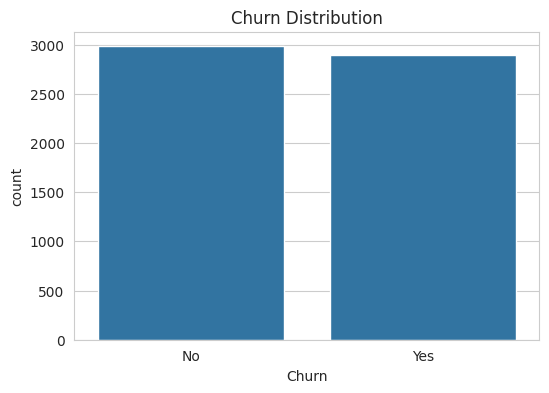

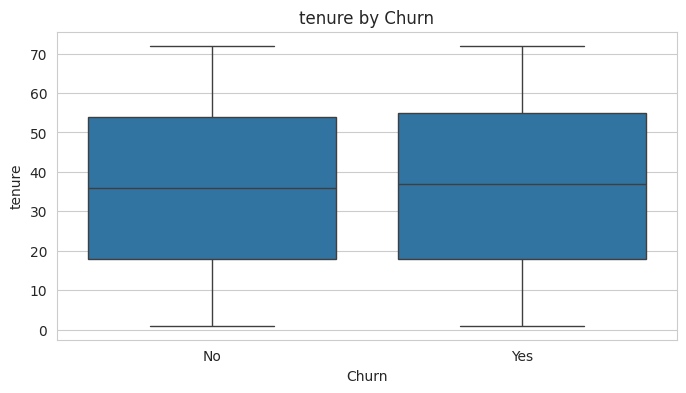

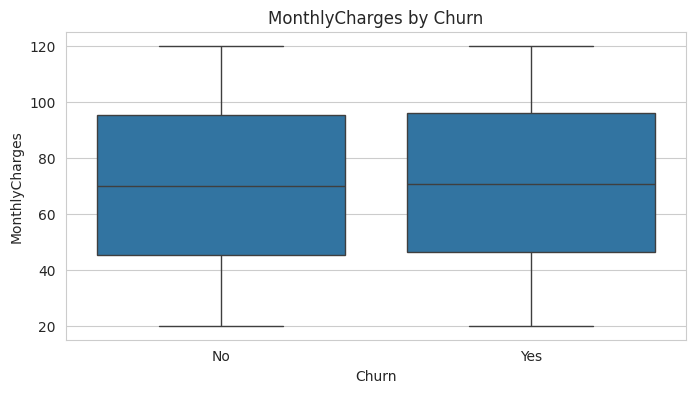

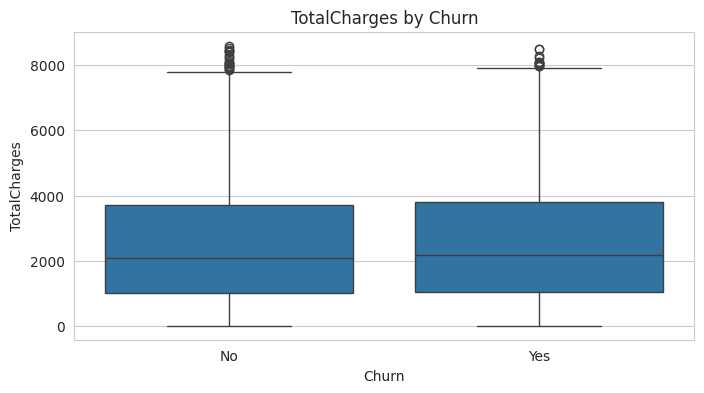

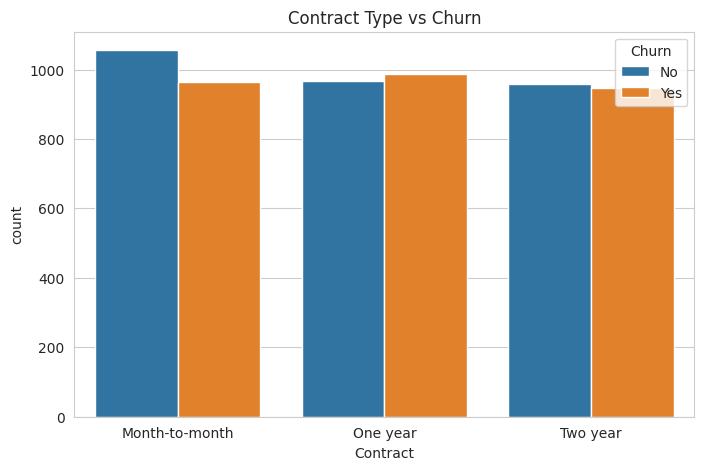

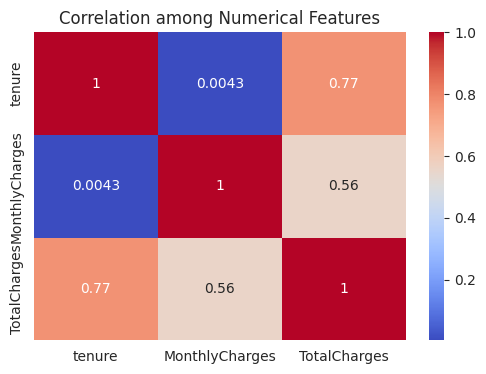

In [13]:
# Set style
sns.set_style('whitegrid')

# 1. Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

# 2. Numerical features vs Churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} by Churn')
    plt.show()

# 3. Categorical feature: Contract type
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.show()

# 4. Correlation heatmap for numerical features
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation among Numerical Features')
plt.show()

In [15]:
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})  # binary encoding

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature matrix shape: (5880, 19)
Target distribution:
 Churn
0    2982
1    2898
Name: count, dtype: int64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 4704 rows
Test set size: 1176 rows


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 4704 rows
Test set size: 1176 rows


In [19]:
# Identify column types
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = X.columns.difference(numeric_features).tolist()

print("Numerical columns:", numeric_features)
print("Categorical columns:", categorical_features)

# Build transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Fit on training data and transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)

Numerical columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['Contract', 'Dependents', 'DeviceProtection', 'InternetService', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'PaperlessBilling', 'Partner', 'PaymentMethod', 'PhoneService', 'SeniorCitizen', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'gender']
Processed training data shape: (4704, 46)



Model: Logistic Regression
Accuracy : 0.5009
Precision: 0.4925
Recall   : 0.3983
F1 Score : 0.4404
ROC-AUC  : 0.4746

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.60      0.55       596
           1       0.49      0.40      0.44       580

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.49      1176
weighted avg       0.50      0.50      0.50      1176



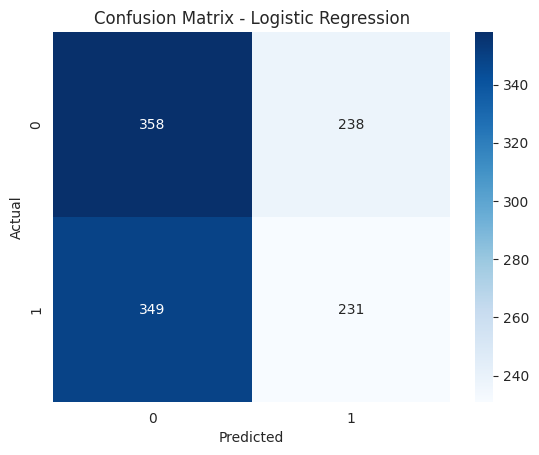

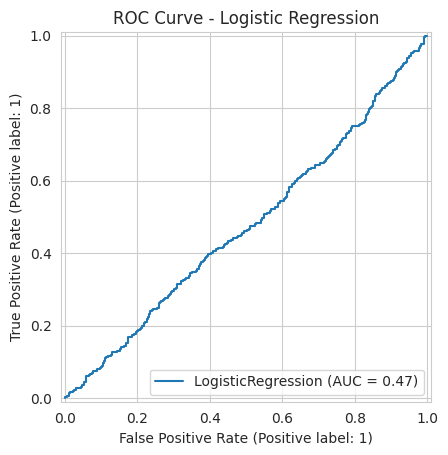


Model: Random Forest
Accuracy : 0.4949
Precision: 0.4874
Recall   : 0.4672
F1 Score : 0.4771
ROC-AUC  : 0.4974

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.52      0.51       596
           1       0.49      0.47      0.48       580

    accuracy                           0.49      1176
   macro avg       0.49      0.49      0.49      1176
weighted avg       0.49      0.49      0.49      1176



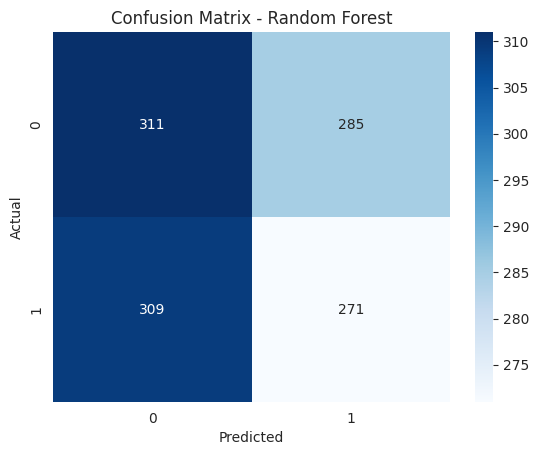

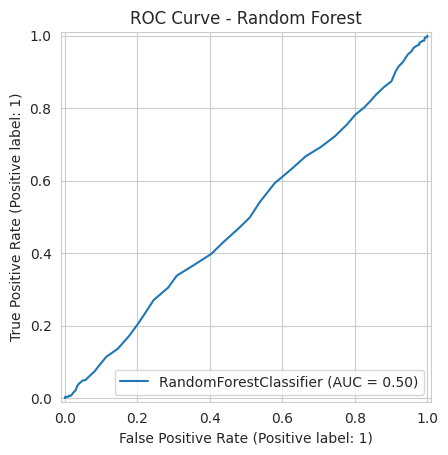


Model: XGBoost
Accuracy : 0.5026
Precision: 0.4957
Recall   : 0.4983
F1 Score : 0.4970
ROC-AUC  : 0.4906

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.51      0.51       596
           1       0.50      0.50      0.50       580

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.50      1176
weighted avg       0.50      0.50      0.50      1176



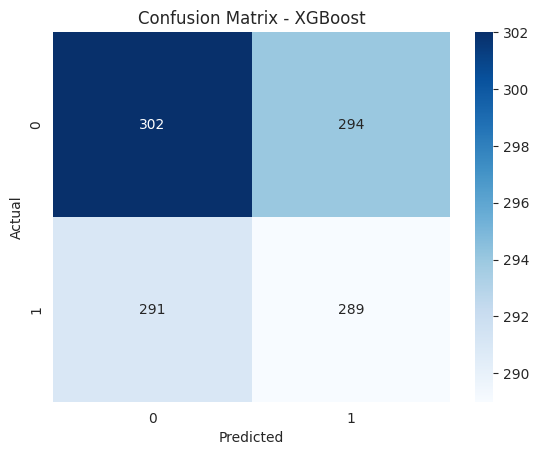

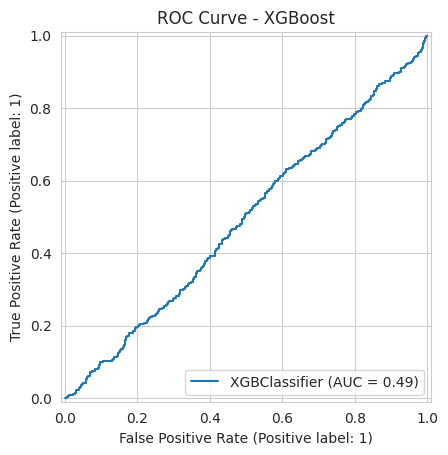



=== Model Performance Summary ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.5009     0.4925  0.3983  0.4404   0.4746
Random Forest          0.4949     0.4874  0.4672  0.4771   0.4974
XGBoost                0.5026     0.4957  0.4983  0.4970   0.4906


In [20]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42,
                             use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': auc
    }

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_estimator(model, X_test_processed, y_test)
    plt.title(f'ROC Curve - {name}')
    plt.show()

# Summary table
results_df = pd.DataFrame(results).T
print("\n\n=== Model Performance Summary ===")
print(results_df.round(4))

In [21]:
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = models[best_model_name]
print(f"Best model based on ROC-AUC: {best_model_name}")
print(f"ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"F1 Score: {results_df.loc[best_model_name, 'F1']:.4f}")

Best model based on ROC-AUC: Random Forest
ROC-AUC: 0.4974
F1 Score: 0.4771


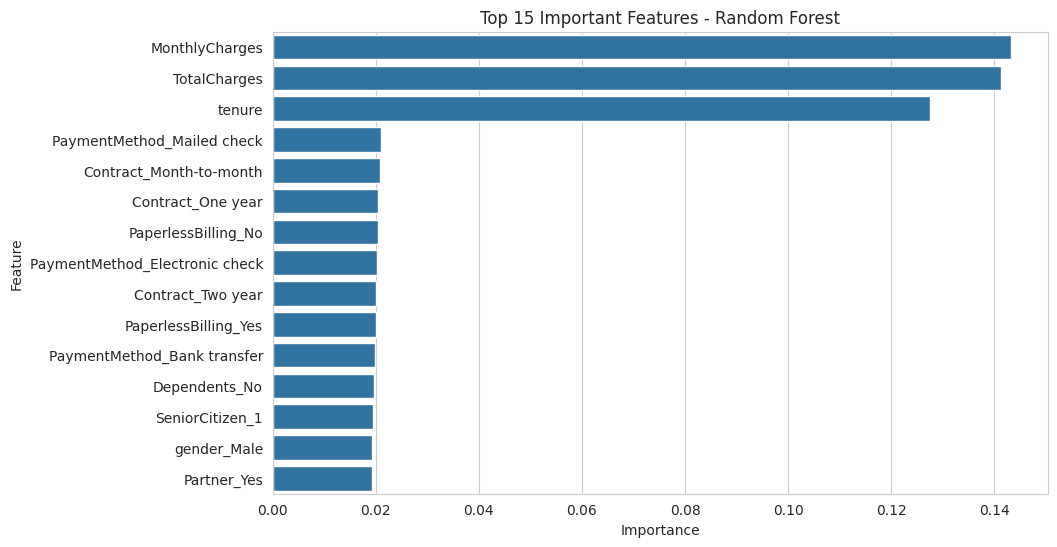

In [22]:
if best_model_name in ['Random Forest', 'XGBoost']:
    # Get feature names after one-hot encoding
    # Retrieve the one-hot encoder from the preprocessor
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = ohe.get_feature_names_out(categorical_features)
    all_feature_names = numeric_features + list(cat_feature_names)

    importances = best_model.feature_importances_
    feat_imp = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp)
    plt.title(f'Top 15 Important Features - {best_model_name}')
    plt.show()
else:
    # For Logistic Regression, show coefficients
    coefs = best_model.coef_[0]
    feat_imp = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefs})
    feat_imp = feat_imp.sort_values('Coefficient', ascending=False).head(10)
    plt.figure(figsize=(10,6))
    sns.barplot(x='Coefficient', y='Feature', data=feat_imp)
    plt.title(f'Top 10 Coefficients - {best_model_name}')
    plt.show()

In [23]:
# Uncomment the lines below if you want to tune the best model (change model as needed)
# param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1],
#     'subsample': [0.8, 1.0]
# }
# grid = GridSearchCV(best_model, param_grid, cv=5, scoring='roc_auc')
# grid.fit(X_train_processed, y_train)
# print("Best parameters:", grid.best_params_)
# best_tuned = grid.best_estimator_
# # Evaluate on test set
# y_pred_tuned = best_tuned.predict(X_test_processed)
# print("Tuned model test ROC-AUC:", roc_auc_score(y_test, best_tuned.predict_proba(X_test_processed)[:,1]))

In [24]:
# Example new customer data (use the same column order as original)
new_customer = pd.DataFrame({
    'gender': ['Female'],
    'SeniorCitizen': [0],
    'Partner': ['Yes'],
    'Dependents': ['No'],
    'tenure': [12],
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['DSL'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['Yes'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['No'],
    'StreamingMovies': ['No'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [75.5],
    'TotalCharges': [906.0]
})

# Preprocess and predict
new_processed = preprocessor.transform(new_customer)
pred = best_model.predict(new_processed)
prob = best_model.predict_proba(new_processed)[:,1]

print(f"Churn Prediction: {'Yes' if pred[0]==1 else 'No'}")
print(f"Probability of Churn: {prob[0]:.4f}")

Churn Prediction: Yes
Probability of Churn: 0.6300
